# Q2 Unsupervised Learning — Customer Segmentation with K-Means + PCA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv(r"C:\Business analytics\ass 4 ml\data\q2_customers.csv")

print("Shape:",df.shape)
df.head()


Shape: (500, 6)


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


## 1 Data Preparation
Scaling is essential before K-Means because distance-based algorithms are sensitive to feature magnitudes.

In [3]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)


## 2 Elbow Method

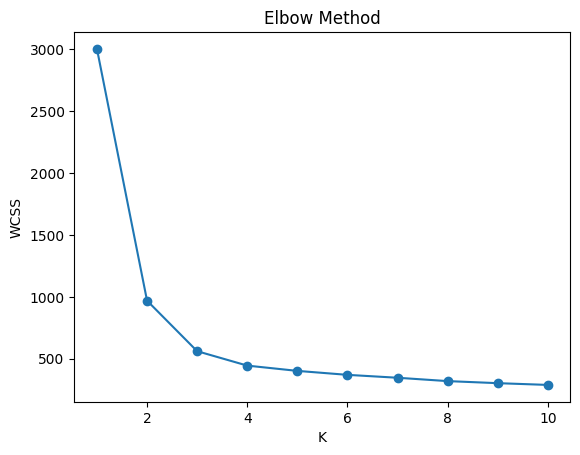

In [4]:
wcss=[]

for k in range(1,11):
    km=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


Interpret the elbow point and justify your selected optimal K below.

## 3 K-Means Clustering

In [5]:
# Change K if elbow suggests another value
optimal_k=4

kmeans=KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters=kmeans.fit_predict(X_scaled)

df['cluster']=clusters

df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [6]:
centroids=pd.DataFrame(
scaler.inverse_transform(kmeans.cluster_centers_),
columns=df.drop('cluster',axis=1).columns
)

print("Cluster Centroids:")
centroids


Cluster Centroids:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,57.037500,89814.075000,2.462500,5296.362500,148.000000,7.487500
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242
3,56.517647,89036.164706,2.588235,5750.952941,65.223529,7.541176


### Business Interpretation of Clusters
Cluster 0: Interpret based on centroid values

Cluster 1: Interpret based on centroid values

Cluster 2: Interpret based on centroid values

Cluster 3: Interpret based on centroid values


## 4 PCA Dimensionality Reduction

In [8]:
pca=PCA(n_components=2)

X_pca=pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)


Explained Variance Ratio:
[0.83560354 0.05568764]


In [9]:
loadings=pd.DataFrame(
pca.components_.T,
columns=['PC1','PC2'],
index=df.drop('cluster',axis=1).columns
)

print("Feature Loadings:")
loadings


Feature Loadings:


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


Interpretation:
PC1 likely captures:
(fill based on highest loadings)

PC2 likely captures:
(fill based on highest loadings)


## 5 Cluster Visualisation

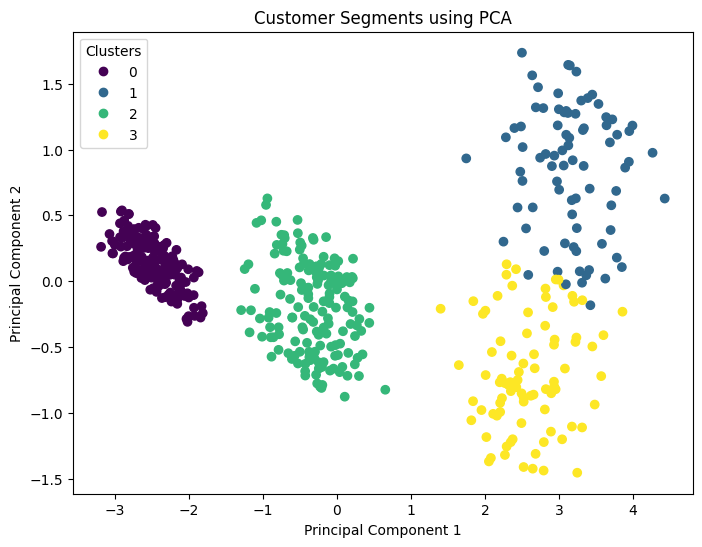

In [10]:
plt.figure(figsize=(8,6))

scatter=plt.scatter(
X_pca[:,0],
X_pca[:,1],
c=clusters,
cmap='viridis'
)

plt.title('Customer Segments using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(
*scatter.legend_elements(),
title='Clusters'
)

plt.show()
